In [ ]:
import os
from dotenv import load_dotenv
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()
API_KEY = os.getenv("NVIDIA")
MODEL = os.getenv("NVIDIA_MODEL")

llm = ChatNVIDIA(model=MODEL, api_key=API_KEY)


@tool
def search_product(product_name: str) -> str:
    """상품 이름으로 상품 정보를 검색합니다."""
    products = {
        "아이폰 17": {"name": "아이폰 17", "price": 150000},
        "아이폰 17 프로": {"name": "아이폰 17 프로", "price": 180000},
        "맥북 에어": {"name": "맥북 에어", "price": 160000},
    }

    product = products.get(product_name)

    if product is None:
        return f"{product_name} 상품을 찾을 수 없습니다."

    return f"상품명: {product['name']}\n가격: {product['price']}원"


@tool
def calculate_discount(price: int, discount_percent: float) -> str:
    """상품 가격과 할인율을 받아 할인된 가격을 계산합니다."""

    discount_amount = price * (discount_percent / 100)

    final_price = price - discount_amount

    return (
        f"원래 가격: {price:,.0f}원\n"
        f"할인율: {discount_percent}%\n"
        f"할인 금액: {discount_amount:,.0f}원\n"
        f"최종 가격: {final_price:,.0f}원"
    )


agent = create_agent(
    model=llm,
    tools=[search_product, calculate_discount],
    system_prompt="""
                    당신은 상품 가격을 안내하는 Agent입니다.

                    사용자가 상품 정보를 요청하면
                    search_product Tool을 사용하세요.

                    할인 가격이나 할인 금액을 계산해야 한다면
                    calculate_discount Tool을 사용하세요.

                    필요한 Tool을 순서대로 사용할 수 있습니다.

                    모든 필요한 정보를 확인한 뒤
                    최종 답변을 작성하세요.
                    """,
)


def agent_node(state: MessagesState):
    result = agent.invoke({"messages": state["messages"]})

    return {"messages": result["messages"]}


tool_node = ToolNode([search_product, calculate_discount])

graph = StateGraph(MessagesState)

graph.add_node("agent", agent_node)

graph.add_node("tools", tool_node)

graph.add_edge(START, "agent")

graph.add_conditional_edges("agent", tools_condition)

graph.add_edge("tools", "agent")

app = graph.compile()

result = app.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": ("아이폰 17의 가격을 찾아서 10% 할인된 가격도 알려주세요."),
            }
        ]
    }
)


print("전체 실행 과정")
print("=" * 70)

for index, message in enumerate(result["messages"]):
    print(f"\n[{index}] {type(message).__name__}")

    if message.content:
        print("내용:")
        print(message.content)

    if getattr(message, "tool_calls", None):
        print("Tool Calls:")
        for tool_call in message.tool_calls:
            print(f"  - {tool_call['name']}")
            print(f"    args: {tool_call['args']}")


print("최종 답변")
print("=" * 70)

print(result["messages"][-1].content)

In [ ]:
import os

from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv

from langchain_nvidia_ai_endpoints import ChatNVIDIA

from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
)

from langgraph.graph import (
    StateGraph,
    START,
    END,
)

from langgraph.graph.message import add_messages

load_dotenv()

API_KEY = os.getenv("NVIDIA")
MODEL = os.getenv("NVIDIA_MODEL")

llm = ChatNVIDIA(model=MODEL, api_key=API_KEY, timeout=600, max_tokens=2048)


class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


def first_node(state: State):
    print("FIRST NODE")

    response = llm.invoke("안녕하세요라고 간단하게 인사해주세요.")

    print("생성된 메세지 : ", response.content)

    return {"messages": [response]}


def second_node(state: State):
    print("SECOND NODE")

    response = llm.invoke("자기소개를 아주 간단하게 해주세요")

    print("생성된 메세지 : ", response.content)

    return {"messages": [response]}


graph = StateGraph(State)

graph.add_node("first", first_node)

graph.add_node("second", second_node)

graph.add_edge(START, "first")
graph.add_edge("first", "second")
graph.add_edge("second", END)

app = graph.compile()

result = app.invoke({"messages": [HumanMessage(content="대화를 시작해주세요.")]})

print("\n\n")
print("=" * 60)
print("최종 State")
print("=" * 60)

for index, message in enumerate(result["messages"]):
    print(f"\n[{index}]")
    print(f"Type: {type(message).__name__}")
    print(f"Content: {message.content}")

In [ ]:
import os

from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv

from langchain_nvidia_ai_endpoints import ChatNVIDIA

from langgraph.graph import (
    StateGraph,
    START,
    END,
)


load_dotenv()

API_KEY = os.getenv("NVIDIA")
MODEL = os.getenv("NVIDIA_MODEL")

llm = ChatNVIDIA(model=MODEL, api_key=API_KEY, timeout=600, max_tokens=2048)


def merge_logs(old_logs: list[str], new_logs: list[str]) -> list[str]:
    merged = old_logs + new_logs

    return list(dict.fromkeys(merged))


class State(TypedDict):
    question: str
    answer: str
    logs: Annotated[list[str], merge_logs]


def search_node(state: State):
    print("search_node")
    response = llm.invoke(
        f"""
        다음 질문에 대해 핵심 정보를 정리해주세요.

        질문:
        {state["question"]}
        """
    )

    print(response.content)

    return {
        "answer": response.content,
        "logs": [
            "검색 시작",
            "검색 완료",
        ],
    }


def analyze_node(state: State):
    print("analyze_node")

    response = llm.invoke(
        f"""
        다음 정보를 분석해주세요.

        원래 질문:
        {state["question"]}

        검색 결과:
        {state["answer"]}
        """
    )

    print(response.content)

    return {"answer": response.content, "logs": ["분석 시작", "분석 완료"]}


def answer_node(state: State):
    print("answer_node")

    response = llm.invoke(
        f"""
        사용자의 질문에 최종 답변을 작성해주세요.

        질문:
        {state["question"]}

        분석 결과:
        {state["answer"]}
        """
    )

    print(response.content)

    return {"answer": response.content, "logs": ["답변 생성"]}


graph = StateGraph(State)

graph.add_node("search", search_node)
graph.add_node("analyze", analyze_node)
graph.add_node("answer", answer_node)

graph.add_edge(START, "search")

graph.add_edge("search", "analyze")

graph.add_edge("analyze", "answer")

graph.add_edge("answer", END)

app = graph.compile()

result = app.invoke(
    {
        "question": "LangGraph에서 Reducer는 왜 필요한가요?",
        "answer": "",
        "logs": [],
    }
)

print("최종 State")
print("=" * 60)

print("\n질문:")
print(result["question"])

print("\n최종 답변:")
print(result["answer"])

print("\n실행 로그:")
for index, log in enumerate(result["logs"], start=1):
    print(f"{index}. {log}")

In [ ]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import InMemorySaver

from const.const import API_KEY, MODEL, EMBEDDING_MODEL

llm = ChatNVIDIA(model=MODEL, api_key=API_KEY, timeout=600, max_completion_tokens=2048)


def chatbot(state: MessagesState):
    """현재 State에 들어있는 모든 messages를 LLM에게 전달합니다."""

    response = llm.invoke(state["messages"])

    return {"messages": [response]}


graph = StateGraph(MessagesState)

graph.add_node("chatbot", chatbot)

graph.add_edge(START, "chatbot")

graph.add_edge("chatbot", END)

checkpointer = InMemorySaver()

app = graph.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "user_1"}}

result1 = app.invoke(
    {"messages": [{"role": "user", "content": "내 이름은 김민수야."}]}, config=config
)

print(result1["messages"][-1].content)

result2 = app.invoke(
    {"messages": [{"role": "user", "content": "내 이름이 뭐노"}]}, config=config
)

print(result2["messages"][-1].content)

current_state = app.get_state(config)

for message in current_state:
    # print(f"{message.type}: {message.content}")
    print("message : ", message)
    print()


config_2 = {"configurable": {"thread_id": "user_2"}}

result3 = app.invoke(
    {"messages": [{"role": "user", "content": "내 이름이 뭐라고 했냐"}]},
    config=config_2,
)

print(result3["messages"][-1].content)

In [ ]:
import sys
from pathlib import Path
from const.const import API_KEY, MODEL, TAVILY_API_KEY
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_tavily import TavilySearch
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from IPython.display import Image, display

# sys.path.append(str(Path.cwd().parent))

OPENAI_API_KEY = API_KEY
TAVILY_API_KEY = TAVILY_API_KEY

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

print("환경 변수 로드 완료")

llm = ChatNVIDIA(model=MODEL, api_key=API_KEY, temperature=0.2)


tavily_tool = TavilySearch(max_results=5)


def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 검색 결과를 list[dict] 형태로 정리한다.

    TavilySearch의 반환값은 보통 {"results": [...]} 형태이다.
    실습에서는 이후 노드가 사용하기 쉽도록 검색 결과 리스트만 추출한다.
    """
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])

    if isinstance(raw_result, list):
        return raw_result

    return []


def format_search_results(results: list[dict]) -> str:
    """검색 결과를 LLM 프롬프트에 넣기 쉬운 문자열로 변환한다."""
    if not results:
        return "검색 결과가 없다."

    lines = []
    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(f"[{idx}] {title}\nURL: {url}\n내용: {content}")

    return "\n\n".join(lines)


def show_graph(app):
    """그래프 구조를 시각화한다.

    Mermaid 이미지 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


class ReportState(TypedDict):
    # 사용자가 입력한 원래 주제이다.
    topic: str

    # Tavily 검색에 사용한 검색어이다.
    search_query: str

    # Tavily에서 받은 검색 결과 목록이다.
    search_results: list[dict]

    # LLM이 작성한 뉴스 리포트이다.
    report: str


def search_node(state: ReportState) -> dict:
    """Tavily 검색을 수행하는 노드이다."""

    query = state["topic"]
    print(f"검색어: {query}")

    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    print(f"검색 결과 수: {len(results)}")

    return {
        "search_query": query,
        "search_results": results,
    }


report_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
너는 검색 결과를 바탕으로 짧은 뉴스 브리핑을 작성하는 AI이다.

작성 규칙:
1. 검색 결과에 있는 내용만 사용한다.
2. 날짜, 수치, 기관명은 원문에 있을 때만 사용한다.
3. 제공되지 않은 정보는 추정하지 않는다.
4. 한국어로 작성한다.
5. 제목, 핵심 요약, 주요 내용, 참고 링크 순서로 정리한다.
""".strip(),
        ),
        (
            "human",
            """
주제: {topic}

검색 결과:
{search_results}

위 검색 결과를 바탕으로 초보자도 이해할 수 있는 뉴스 리포트를 작성하라.
""".strip(),
        ),
    ]
)

# 프롬프트 → LLM → 문자열 출력 파서 순서로 실행되는 LangChain 체인이다.
report_chain = report_prompt | llm | StrOutputParser()


def report_node(state: ReportState) -> dict:
    """검색 결과를 바탕으로 뉴스 리포트를 작성하는 노드이다."""

    # 검색 결과를 프롬프트에 넣기 좋은 문자열로 변환한다.
    search_text = format_search_results(state["search_results"])

    # LLM 체인을 실행해 리포트를 생성한다.
    report = report_chain.invoke(
        {
            "topic": state["topic"],
            "search_results": search_text,
        }
    )

    return {"report": report}


builder = StateGraph(ReportState)

# 두 개의 노드를 등록한다.
builder.add_node("검색", search_node)
builder.add_node("리포트작성", report_node)

# 순차 실행 흐름을 정의한다.
builder.add_edge(START, "검색")
builder.add_edge("검색", "리포트작성")
builder.add_edge("리포트작성", END)

app = builder.compile()

show_graph(app)


result = app.invoke(
    {
        "topic": "인공지능 최신 동향",
        "search_query": "",
        "search_results": [],
        "report": "",
    }
)

print(result["report"])

In [ ]:
# import sys
# from pathlib import Path

# sys.path.append(str(Path.cwd().parent))

from const.const import create_model

# LangGraph, LLM, Tavily 검색 도구를 불러온다.
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from IPython.display import Image, display

# LLM은 검색 결과를 자연어 리포트로 정리할 때 사용한다.
llm = create_model()

# TavilySearch는 외부 웹 검색을 수행하는 도구이다.
tavily_tool = TavilySearch(max_results=5)


def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 검색 결과를 list[dict] 형태로 정리한다.

    TavilySearch의 반환값은 보통 {"results": [...]} 형태이다.
    실습에서는 이후 노드가 사용하기 쉽도록 검색 결과 리스트만 추출한다.
    """
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])

    if isinstance(raw_result, list):
        return raw_result

    return []


def format_search_results(results: list[dict]) -> str:
    """검색 결과를 LLM 프롬프트에 넣기 쉬운 문자열로 변환한다."""
    if not results:
        return "검색 결과가 없다."

    lines = []
    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(f"[{idx}] {title}\nURL: {url}\n내용: {content}")

    return "\n\n".join(lines)


def show_graph(app):
    """그래프 구조를 시각화한다.

    Mermaid 이미지 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


class AdvancedNewsState(TypedDict):
    # 사용자가 입력한 원래 주제이다.
    topic: str

    # 현재 Tavily 검색에 사용할 검색어이다.
    search_query: str

    # 현재 검색 결과 목록이다.
    search_results: list[dict]

    # 검색 결과가 리포트 작성에 충분한지 표시한다.
    is_sufficient: bool

    # 검증 결과나 재검색 이유를 저장한다.
    feedback: str

    # 검색이 몇 번 실행되었는지 저장한다.
    search_count: int

    # 최종 리포트이다.
    report: str


def search_node(state: AdvancedNewsState) -> dict:
    """현재 검색어로 Tavily 검색을 수행하는 노드이다."""

    # search_query가 비어 있으면 topic을 검색어로 사용한다.
    query = state.get("search_query") or state["topic"]

    # 검색 횟수를 1 증가시킨다.
    search_count = state.get("search_count", 0) + 1

    print(f"[{search_count}회차 검색] {query}")

    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    print(f"검색 결과 수: {len(results)}")

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


MAX_SEARCH_COUNT = 2


def validate_node(state: AdvancedNewsState) -> dict:
    """검색 결과가 충분한지 판단하는 노드이다."""

    results = state["search_results"]
    search_count = state["search_count"]

    # 초보자 실습에서는 검색 결과 개수만으로 충분성을 판단한다.
    has_enough_results = len(results) >= 3

    # 무한 재검색을 막기 위해 최대 검색 횟수를 제한한다.
    reached_limit = search_count >= MAX_SEARCH_COUNT

    if has_enough_results:
        return {
            "is_sufficient": True,
            "feedback": "검색 결과가 충분하다.",
        }

    if reached_limit:
        return {
            "is_sufficient": True,
            "feedback": "검색 결과가 충분하지 않지만 최대 검색 횟수에 도달해 리포트를 작성한다.",
        }

    return {
        "is_sufficient": False,
        "feedback": "검색 결과가 부족하다. 더 구체적인 검색어가 필요하다.",
    }


rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            너는 웹 검색어를 개선하는 AI이다.
            사용자의 주제와 피드백을 바탕으로 더 구체적인 한국어 검색어 하나만 작성한다.
            설명 없이 검색어만 출력한다.
            """.strip(),
        ),
        (
            "human",
            """
            원래 주제: {topic}
            현재 검색어: {search_query}
            피드백: {feedback}

            개선된 검색어:
            """.strip(),
        ),
    ]
)

rewrite_chain = rewrite_prompt | llm | StrOutputParser()


def rewrite_query_node(state: AdvancedNewsState) -> dict:
    """검색 결과가 부족할 때 검색어를 다시 작성하는 노드이다."""

    new_query = rewrite_chain.invoke(
        {
            "topic": state["topic"],
            "search_query": state["search_query"],
            "feedback": state["feedback"],
        }
    ).strip()

    print(f"재작성된 검색어: {new_query}")

    return {"search_query": new_query}


report_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            너는 검색 결과를 바탕으로 짧은 뉴스 브리핑을 작성하는 AI이다.

            작성 규칙:
            1. 검색 결과에 있는 내용만 사용한다.
            2. 날짜, 수치, 기관명은 원문에 있을 때만 사용한다.
            3. 제공되지 않은 정보는 추정하지 않는다.
            4. 검색 결과가 부족하면 한계를 명시한다.
            5. 한국어로 작성한다.
            """.strip(),
        ),
        (
            "human",
            """
주제: {topic}
검색어: {search_query}
검증 피드백: {feedback}

검색 결과:
{search_results}

위 내용을 바탕으로 뉴스 리포트를 작성하라.
""".strip(),
        ),
    ]
)

report_chain = report_prompt | llm | StrOutputParser()


def report_node(state: AdvancedNewsState) -> dict:
    """검색 결과를 바탕으로 최종 리포트를 작성하는 노드이다."""

    search_text = format_search_results(state["search_results"])

    report = report_chain.invoke(
        {
            "topic": state["topic"],
            "search_query": state["search_query"],
            "feedback": state["feedback"],
            "search_results": search_text,
        }
    )

    return {"report": report}


def route_after_validation(state: AdvancedNewsState) -> str:
    """검증 결과에 따라 다음 노드를 선택한다."""

    if state["is_sufficient"]:
        return "리포트작성"

    return "검색어재작성"


builder = StateGraph(AdvancedNewsState)

builder.add_node("검색", search_node)
builder.add_node("검증", validate_node)
builder.add_node("검색어재작성", rewrite_query_node)
builder.add_node("리포트작성", report_node)

builder.add_edge(START, "검색")
builder.add_edge("검색", "검증")

# 검증 결과에 따라 리포트 작성 또는 검색어 재작성으로 분기한다.
builder.add_conditional_edges(
    "검증",
    route_after_validation,
    {
        "리포트작성": "리포트작성",
        "검색어재작성": "검색어재작성",
    },
)

# 검색어를 다시 작성하면 검색 노드로 돌아간다.
builder.add_edge("검색어재작성", "검색")

builder.add_edge("리포트작성", END)

app = builder.compile()

show_graph(app)


initial_state = {
    "topic": "인공지능 최신 동향",
    "search_query": "",
    "search_results": [],
    "is_sufficient": False,
    "feedback": "",
    "search_count": 0,
    "report": "",
}

result = app.invoke(initial_state)

print("최종 검색어:", result["search_query"])
print("검색 횟수:", result["search_count"])
print("검증 피드백:", result["feedback"])
print("\n[최종 리포트]")
print(result["report"])


# for event in app.stream(initial_state, stream_mode="updates"):
#     print(f"event.keys() : {event.keys()}")
#     print(f"event: {event}")
#     print("-" * 80)

In [ ]:
for event in app.stream(
    {
        "topic": "생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기",
        "search_query": "",
        "search_results": [],
        "report": "",
    },
    stream_mode="updates",
):
    for update_data in event.values():
        if "search_results" in update_data:
            for i, item in enumerate(update_data["search_results"], start=1):
                print(f"\n[{i}] {item.get('title')}")
                print(item.get("url"))
                print(item.get("content"))

In [ ]:
# import sys
# from pathlib import Path

# sys.path.append(str(Path.cwd().parent))

from const.const import create_model
from datetime import datetime
from typing_extensions import TypedDict
from IPython.display import Image, display

from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_tavily import TavilySearch
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langgraph.graph import StateGraph, START, END

# 최신 뉴스 검색과 리포트 작성에 사용할 현재 날짜이다.
TODAY = datetime.now().strftime("%Y-%m-%d")

# LLM은 요약, 검색어 재작성, 리포트 작성에 사용한다.
llm = create_model()

# Tavily Search 도구를 초기화한다.
# topic="news"는 뉴스 검색에 맞춘 범주이다.
# time_range="month"는 최근 1개월 자료를 우선 검색하도록 한다.
tavily_tool = TavilySearch(
    max_results=5,
    topic="news",
    search_depth="advanced",
    time_range="month",
)

print("준비 완료")
print("오늘 날짜:", TODAY)


def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 반환값에서 실제 검색 결과 리스트만 추출한다.

    최신 TavilySearch는 {"results": [...]} 형태를 주로 반환한다.
    수업 환경 차이를 고려해 리스트가 바로 들어오는 경우도 함께 처리한다.
    """
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])

    if isinstance(raw_result, list):
        return raw_result

    return []


def show_graph(app) -> None:
    """LangGraph 구조를 시각화한다.

    Mermaid PNG 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


MAX_SEARCH_COUNT = 3  # 최초 검색 1회 + 재검색 최대 2회


class SummaryNewsState(TypedDict):
    topic: str  # 사용자가 입력한 원래 주제
    search_query: str  # Tavily에 전달할 실제 검색어
    search_results: list[dict]  # Tavily 검색 원본 결과
    summaries: list[dict]  # 기사별 요약 결과
    is_sufficient: bool  # 검증 통과 여부
    feedback: str  # 검증 결과 또는 개선 피드백
    report: str  # 최종 리포트
    search_count: int  # 검색 실행 횟수


print("State 필드")
for field in SummaryNewsState.__annotations__:
    print("-", field)


def search_node(state: SummaryNewsState) -> dict:
    """Tavily Search API로 뉴스 검색을 수행한다."""

    # search_query가 비어 있으면 원래 topic을 검색어로 사용한다.
    query = state.get("search_query") or state["topic"]

    # 검색 횟수를 증가시켜 재검색 루프의 안전장치로 사용한다.
    search_count = state.get("search_count", 0) + 1

    print(f"  [검색 #{search_count}] 검색어: {query}")

    # TavilySearch는 {"query": "..."} 형태로 호출한다.
    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    print(f"  [검색] {len(results)}개 문서 수집")

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


summary_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """뉴스 기사를 한국어로 2~3문장 요약한다.

            규칙:
            - 기사에 있는 정보만 사용한다.
            - 날짜가 제공된 경우에만 날짜를 포함한다.
            - 날짜, 수치, 기관명, 제품명은 추정하지 않는다.
            - 원문에 없는 해석이나 과장된 표현을 추가하지 않는다.""",
        ),
        (
            "human",
            """제목: {title}
            URL: {url}

            내용:
            {content}""",
        ),
    ]
)

summary_chain = summary_prompt | llm | StrOutputParser()


def summarize_node(state: SummaryNewsState) -> dict:
    """검색 결과를 기사별 요약으로 변환한다."""

    results = state.get("search_results", [])
    summaries: list[dict] = []

    print(f"  [요약] {len(results)}개 문서 요약 시작")

    for result in results:
        title = result.get("title", "제목 없음")
        url = result.get("url", "")
        content = result.get("content", "")

        # content가 없으면 LLM이 근거 없는 요약을 만들 수 있으므로 건너뛴다.
        if not content.strip():
            continue

        summary = summary_chain.invoke(
            {
                "title": title,
                "url": url,
                "content": content[:1200],  # 비용과 속도를 고려해 일부 내용만 사용한다.
            }
        )

        summaries.append(
            {
                "title": title,
                "url": url,
                "summary": summary,
            }
        )

        print(f"    - 요약 완료: {title[:50]}")

    return {"summaries": summaries}


def verify_node(state: SummaryNewsState) -> dict:
    """요약 결과가 최종 리포트 작성에 충분한지 검증한다."""

    summaries = state.get("summaries", [])

    valid_summaries = [
        item
        for item in summaries
        if item.get("url") and len(item.get("summary", "")) >= 50
    ]

    is_sufficient = len(valid_summaries) >= 3

    if is_sufficient:
        feedback = "유효한 기사 요약이 3개 이상이다."
    else:
        feedback = (
            f"유효한 기사 요약이 {len(valid_summaries)}개이다. "
            "출처 URL이 있고 요약 길이가 충분한 뉴스가 더 필요하다."
        )

    print(f"  [검증] 유효 요약 {len(valid_summaries)}개 → 충분 여부: {is_sufficient}")

    return {
        "is_sufficient": is_sufficient,
        "feedback": feedback,
    }


rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """검색 결과가 부족할 때 사용할 새 검색어를 작성한다.
            규칙:
            - 검색어 한 줄만 출력한다.
            - 따옴표, 번호, 설명 문장을 붙이지 않는다.
            - 오늘 날짜는 {today}이다.
            - 최신 뉴스 검색에 적합하도록 최근성 표현을 포함한다.
            - 이전 검색어와 너무 비슷하게 작성하지 않는다.""",
        ),
        (
            "human",
            """원래 주제: {topic}
            이전 검색어: {search_query}
            검증 피드백: {feedback}

            새 검색어:""",
        ),
    ]
)

rewrite_chain = rewrite_prompt | llm | StrOutputParser()


def rewrite_query_node(state: SummaryNewsState) -> dict:
    """검증 실패 시 검색어를 재작성한다."""

    new_query = rewrite_chain.invoke(
        {
            "today": TODAY,
            "topic": state["topic"],
            "search_query": state.get("search_query", ""),
            "feedback": state.get("feedback", ""),
        }
    ).strip()

    # LLM이 빈 문자열을 반환하면 기본 검색어를 사용한다.
    if not new_query:
        new_query = f"{state['topic']} 최신 뉴스 최근 발표"

    print(f"  [검색어재작성] {new_query}")

    return {"search_query": new_query}


report_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """뉴스 요약을 바탕으로 구조화된 브리핑 리포트를 작성한다.

규칙:
- 한국어로 작성한다.
- 출처 URL을 기사별로 반드시 포함한다.
- 검색 결과가 부족하면 부족하다는 점을 명시한다.
- 원문에 없는 날짜, 수치, 기관명을 만들지 않는다.
- 마크다운 형식으로 작성한다.

출력 형식:

## 뉴스 브리핑: {topic}

### 검색 개요
- 검색어:
- 검색 횟수:
- 기사 요약 수:
- 검증 결과:

### 주요 내용
2~3개 문장으로 요약한다.

### 기사별 요약
번호별로 제목, 요약, 출처 URL을 정리한다.

### 종합 인사이트
교육, 연구, 실무 관점에서 활용 가능한 시사점을 2~3문장으로 정리한다.""",
        ),
        (
            "human",
            """오늘 날짜: {today}
원래 주제: {topic}
마지막 검색어: {search_query}
검색 횟수: {search_count}
기사 요약 수: {count}
검증 결과: {feedback}

기사별 요약:
{summaries}""",
        ),
    ]
)

report_chain = report_prompt | llm | StrOutputParser()


def report_node(state: SummaryNewsState) -> dict:
    """최종 뉴스 브리핑 리포트를 생성한다."""

    summaries = state.get("summaries", [])

    if summaries:
        summaries_text = "\n\n".join(
            f"[{i + 1}] {item['title']}\n요약: {item['summary']}\n출처: {item['url']}"
            for i, item in enumerate(summaries)
        )
    else:
        summaries_text = "수집된 기사 요약이 없다."

    print("  [리포트작성] 최종 리포트 생성")

    report = report_chain.invoke(
        {
            "today": TODAY,
            "topic": state["topic"],
            "search_query": state.get("search_query", ""),
            "search_count": state.get("search_count", 0),
            "count": len(summaries),
            "feedback": state.get("feedback", ""),
            "summaries": summaries_text,
        }
    )

    return {"report": report}


def route_after_verify(state: SummaryNewsState) -> str:
    """검증 결과에 따라 다음 노드를 선택한다."""

    if state["is_sufficient"]:
        print("  [결정] 검증 통과 → 리포트작성")
        return "리포트작성"

    if state.get("search_count", 0) >= MAX_SEARCH_COUNT:
        print("  [결정] 최대 검색 횟수 도달 → 리포트작성")
        return "리포트작성"

    print("  [결정] 결과 부족 → 검색어재작성")
    return "검색어재작성"


builder = StateGraph(SummaryNewsState)

# 노드 등록
builder.add_node("검색", search_node)
builder.add_node("요약", summarize_node)
builder.add_node("검증", verify_node)
builder.add_node("검색어재작성", rewrite_query_node)
builder.add_node("리포트작성", report_node)

# 기본 흐름: 검색 → 요약 → 검증
builder.add_edge(START, "검색")
builder.add_edge("검색", "요약")
builder.add_edge("요약", "검증")

# 조건부 Edge: 검증 결과에 따라 리포트 작성 또는 재검색 루프로 이동한다.
builder.add_conditional_edges(
    "검증",
    route_after_verify,
    {
        "리포트작성": "리포트작성",
        "검색어재작성": "검색어재작성",
    },
)

# 검색어를 재작성한 뒤 다시 검색한다.
builder.add_edge("검색어재작성", "검색")

# 리포트 작성 후 종료한다.
builder.add_edge("리포트작성", END)

app = builder.compile()

print("그래프 컴파일 완료")


show_graph(app)


initial_state: SummaryNewsState = {
    "topic": "생성형 AI 교육 트렌드",
    "search_query": "",
    "search_results": [],
    "summaries": [],
    "is_sufficient": False,
    "feedback": "",
    "report": "",
    "search_count": 0,
}

result = app.invoke(initial_state)

print("\n" + "=" * 70)
print("최종 실행 결과")
print("=" * 70)
print("검색 횟수:", result["search_count"])
print("기사 요약 수:", len(result["summaries"]))
print("검증 결과:", result["feedback"])
print("\n" + result["report"])

## 문제 1


In [ ]:
# 문제 1

from const.const import create_model
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

llm = create_model()


class ReportState(TypedDict):
    """뉴스 리포트 파이프라인에서 공유하는 State이다."""

    # 사용자가 입력한 원래 주제이다.
    topic: str

    # 실제 검색에 사용한 검색어이다.
    search_query: str

    # 검색 결과 목록이다.
    search_results: list[dict]

    # 최종 뉴스 리포트이다.
    report: str


def format_search_results(results: list[dict]) -> str:
    """검색 결과를 리포트 작성에 사용할 수 있는 문자열로 변환한다."""

    if not results:
        return "검색 결과가 없다."

    lines = []

    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(f"[{idx}] {title}\nURL: {url}\n내용: {content}")

    return "\n\n".join(lines)


def show_graph(app) -> None:
    """LangGraph 구조를 시각화한다.

    1차: Mermaid PNG 이미지 출력
    2차: ASCII 그래프 출력
    3차: Mermaid 코드 텍스트 출력
    """

    graph = app.get_graph()

    try:
        display(Image(graph.draw_mermaid_png()))
        return
    except Exception as e:
        print(f"Mermaid PNG 생성 실패: {e}")

    try:
        print(graph.draw_ascii())
        return
    except Exception as e:
        print(f"ASCII 그래프 생성 실패: {e}")

    print("Mermaid 코드로 대체 출력한다.")
    print(graph.draw_mermaid())


def search_node(state: ReportState) -> dict:
    """검색 노드이다.

    실제 Tavily API를 호출하지 않고, 수업용 가짜 검색 결과를 반환한다.
    그래프 설계 실습에서는 외부 API보다 노드 연결 구조가 더 중요하다.
    """

    query = state["topic"]
    print(f"[검색] 검색어: {query}")

    results = [
        {
            "title": f"{query} 관련 기사 1",
            "url": "https://example.com/news-1",
            "content": f"{query}와 관련된 주요 변화와 산업 동향을 설명하는 기사이다.",
        },
        {
            "title": f"{query} 관련 기사 2",
            "url": "https://example.com/news-2",
            "content": f"{query}의 교육, 기업 활용, 정책적 쟁점을 다루는 기사이다.",
        },
        {
            "title": f"{query} 관련 기사 3",
            "url": "https://example.com/news-3",
            "content": f"{query}가 현장 실무와 학습 방식에 미치는 영향을 정리한 기사이다.",
        },
    ]

    return {
        "search_query": query,
        "search_results": results,
    }


def report_node(state: ReportState) -> dict:
    """리포트 작성 노드이다.

    검색 결과를 바탕으로 간단한 뉴스 브리핑을 만든다.
    실제 LLM 호출 대신 문자열 조합 방식으로 처리한다.
    """

    search_text = format_search_results(state["search_results"])

    report = f"""# 뉴스 리포트: {state["topic"]}

        ## 핵심 요약
        - 검색어 `{state["search_query"]}`를 기준으로 관련 기사 {len(state["search_results"])}건을 확인했다.
        - 주요 내용은 산업 동향, 교육 활용, 현장 적용 가능성으로 정리할 수 있다.

        ## 검색 결과 정리
        {search_text}

        ## 수업 관점 정리
        이 그래프는 `검색` 노드와 `리포트작성` 노드를 순차적으로 연결하는 기본 파이프라인 구조이다.
        """

    print("[리포트작성] 리포트 생성 완료")

    return {"report": report}


builder = StateGraph(ReportState)

# TODO 1. 노드를 등록한다.
# builder.add_node("검색", ...)
# builder.add_node("리포트작성", ...)
builder.add_node("검색", search_node)
builder.add_node("리포트작성", report_node)

# TODO 2. Edge를 연결한다.
# START → 검색
# 검색 → 리포트작성
# 리포트작성 → END
builder.add_edge(START, "검색")
builder.add_edge("검색", "리포트작성")
builder.add_edge("리포트작성", END)

# TODO 3. 그래프를 컴파일한다.
app = builder.compile()

# TODO 4. 그래프를 시각화한다.
show_graph(app)


initial_state: ReportState = {
    "topic": "생성형 AI 교육 트렌드",
    "search_query": "",
    "search_results": [],
    "report": "",
}

result = app.invoke(initial_state)

print("=" * 70)
print("최종 리포트")
print("=" * 70)
print(result["report"])


# 완성된 그래프의 Mermaid 코드를 출력한다.
# 환경에 따라 이미지 렌더링은 지원되지 않을 수 있다.
from IPython.display import Image, display


def show_graph(app) -> None:
    """LangGraph 구조를 시각화한다.

    Mermaid PNG 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


show_graph(app)


for event in app.stream(
    {
        "topic": "AI 에이전트 최신 동향",
        "search_query": "",
        "search_results": [],
        "report": "",
    },
    stream_mode="updates",
):
    print(event)

## 문제 2


/Users/parkchanryong/Desktop/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:250: UserWarning: Found z-ai/glm-5.3-flash in available_models, but type is unknown and inference may fail.
  warnings.warn(


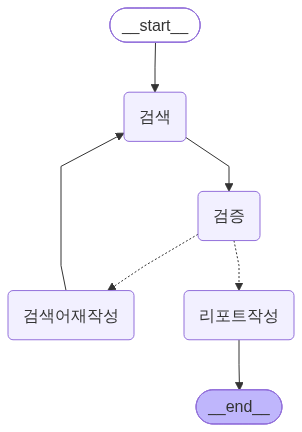

[검색 #1] 검색어: 생성형 AI 교육 트렌드
[검증] 충분 여부: False / 검색 결과가 부족하다. 검색어 재작성이 필요하다.
[검색어재작성] 새 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
[검색 #2] 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
[검증] 충분 여부: True / 검색 결과가 충분하다.
[리포트작성] 최종 리포트 생성 완료

최종 State 확인
최종 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
검색 횟수: 2
검증 피드백: 검색 결과가 충분하다.

최종 리포트
# 뉴스 리포트: 생성형 AI 교육 트렌드

- 최종 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
- 검색 횟수: 2
- 검증 피드백: 검색 결과가 충분하다.

## 검색 결과 요약
1. 생성형 AI 교육 트렌드 최신 동향 사례 관련 기사 1
   - URL: https://example.com/article-1
   - 내용: 충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다.
2. 생성형 AI 교육 트렌드 최신 동향 사례 관련 기사 2
   - URL: https://example.com/article-2
   - 내용: 충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다.
3. 생성형 AI 교육 트렌드 최신 동향 사례 관련 기사 3
   - URL: https://example.com/article-3
   - 내용: 충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다.
4. 생성형 AI 교육 트렌드 최신 동향 사례 관련 기사 4
   - URL: https://example.com/article-4
   - 내용: 충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다.
[검색 #1] 검색어: 생성형 AI 교육 트렌드
{'검색': {'search_query': '생성형 AI 교육 트렌드', 'search_result

In [ ]:
# 문제 2


from const.const import create_model
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

llm = create_model()


class AdvancedNewsState(TypedDict):
    """뉴스 검색 리포트 그래프에서 공유하는 State이다."""

    # 사용자가 입력한 원래 주제이다.
    topic: str

    # 현재 검색에 사용할 검색어이다.
    search_query: str

    # 현재 검색 결과 목록이다.
    search_results: list[dict]

    # 검색 결과가 리포트 작성에 충분한지 여부이다.
    is_sufficient: bool

    # 검증 결과나 재검색 이유이다.
    feedback: str

    # 검색이 몇 번 실행되었는지 저장한다.
    search_count: int

    # 최종 리포트이다.
    report: str


def show_graph(app) -> None:
    """LangGraph 구조를 시각화한다.

    1차: Mermaid PNG 이미지 출력
    2차: ASCII 그래프 출력
    3차: Mermaid 코드 텍스트 출력
    """
    graph = app.get_graph()

    try:
        display(Image(graph.draw_mermaid_png()))
        return
    except Exception as e:
        print(f"Mermaid PNG 생성 실패: {e}")

    try:
        print(graph.draw_ascii())
        return
    except Exception as e:
        print(f"ASCII 그래프 생성 실패: {e}")

    print("Mermaid 코드로 대체 출력한다.")
    print(graph.draw_mermaid())


def search_node(state: AdvancedNewsState) -> dict:
    """검색 노드이다.

    실제 Tavily API 대신 가짜 검색 결과를 반환한다.
    첫 번째 검색은 결과가 부족하고, 두 번째 검색은 결과가 충분하도록 구성되어 있다.
    """

    query = state.get("search_query") or state["topic"]
    search_count = state.get("search_count", 0) + 1

    print(f"[검색 #{search_count}] 검색어: {query}")

    if search_count == 1:
        results = [
            {
                "title": f"{query} 관련 짧은 기사",
                "url": "https://example.com/short",
                "content": "짧은 검색 결과",
            }
        ]
    else:
        results = [
            {
                "title": f"{query} 관련 기사 {i}",
                "url": f"https://example.com/article-{i}",
                "content": "충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다.",
            }
            for i in range(1, 5)
        ]

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


MAX_SEARCH_COUNT = 3


def validate_node(state: AdvancedNewsState) -> dict:
    """검증 노드이다.

    검색 결과가 3개 이상이면 충분하다고 판단한다.
    단, 최대 검색 횟수에 도달하면 부족하더라도 리포트 작성 단계로 넘어가게 한다.
    """

    results = state["search_results"]
    search_count = state["search_count"]

    has_enough_results = len(results) >= 3
    reached_limit = search_count >= MAX_SEARCH_COUNT

    if has_enough_results:
        feedback = "검색 결과가 충분하다."
        is_sufficient = True

    elif reached_limit:
        feedback = (
            "검색 결과가 부족하지만 최대 검색 횟수에 도달했으므로 리포트를 작성한다."
        )
        is_sufficient = True

    else:
        feedback = "검색 결과가 부족하다. 검색어 재작성이 필요하다."
        is_sufficient = False

    print(f"[검증] 충분 여부: {is_sufficient} / {feedback}")

    return {
        "is_sufficient": is_sufficient,
        "feedback": feedback,
    }


def rewrite_query_node(state: AdvancedNewsState) -> dict:
    """검색어 재작성 노드이다.

    실제 LLM 대신 규칙 기반으로 검색어를 보완한다.
    """

    new_query = f"{state['topic']} 최신 동향 사례"

    print(f"[검색어재작성] 새 검색어: {new_query}")

    return {"search_query": new_query}


def report_node(state: AdvancedNewsState) -> dict:
    """리포트 작성 노드이다."""

    lines = [
        f"# 뉴스 리포트: {state['topic']}",
        "",
        f"- 최종 검색어: {state['search_query']}",
        f"- 검색 횟수: {state['search_count']}",
        f"- 검증 피드백: {state['feedback']}",
        "",
        "## 검색 결과 요약",
    ]

    for i, item in enumerate(state["search_results"], start=1):
        lines.append(f"{i}. {item['title']}")
        lines.append(f"   - URL: {item['url']}")
        lines.append(f"   - 내용: {item['content']}")

    report = "\n".join(lines)

    print("[리포트작성] 최종 리포트 생성 완료")

    return {"report": report}


def route_after_validation(state: AdvancedNewsState) -> str:
    """검증 결과에 따라 다음 노드를 선택한다."""

    # TODO 1.
    # 검색 결과가 충분하면 "리포트작성"을 반환한다.
    if state["is_sufficient"]:
        return "리포트작성"
    else:
        return "검색어재작성"
    # TODO 2.
    # 검색 결과가 부족하면 "검색어재작성"을 반환한다.


builder = StateGraph(AdvancedNewsState)

# TODO 3. 노드 등록
builder.add_node("검색", search_node)
builder.add_node("검증", validate_node)
builder.add_node("검색어재작성", rewrite_query_node)
builder.add_node("리포트작성", report_node)

# TODO 4. 기본 Edge 연결
# START → 검색 → 검증
builder.add_edge(START, "검색")
builder.add_edge("검색", "검증")

# TODO 5. 조건부 Edge 연결
# 검증 → 리포트작성
# 검증 → 검색어재작성
builder.add_conditional_edges(
    "검증",
    route_after_validation,
    {"리포트작성": "리포트작성", "검색어재작성": "검색어재작성"},
)
# TODO 6. 재검색 루프 연결
# 검색어재작성 → 검색
builder.add_edge("검색어재작성", "검색")

# TODO 7. 종료 Edge 연결
# 리포트작성 → END
builder.add_edge("리포트작성", END)

# TODO 8. 그래프 컴파일
app = builder.compile()


# TODO 9. 그래프 시각화
show_graph(app)

initial_state: AdvancedNewsState = {
    "topic": "생성형 AI 교육 트렌드",
    "search_query": "",
    "search_results": [],
    "is_sufficient": False,
    "feedback": "",
    "search_count": 0,
    "report": "",
}

result = app.invoke(initial_state)

print("\n" + "=" * 70)
print("최종 State 확인")
print("=" * 70)
print("최종 검색어:", result["search_query"])
print("검색 횟수:", result["search_count"])
print("검증 피드백:", result["feedback"])

print("\n" + "=" * 70)
print("최종 리포트")
print("=" * 70)
print(result["report"])


for event in app.stream(initial_state, stream_mode="updates"):
    print(event)
    print("-" * 80)


## 문제 3


In [ ]:
# 문제3

from const.const import create_model
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

MAX_SEARCH_COUNT = 3

llm = create_model()


class SimpleNewsState(TypedDict):
    # 사용자가 입력한 원래 주제
    topic: str

    # 현재 검색어
    search_query: str

    # 검색 결과 목록
    search_results: list[dict]

    # 기사별 요약 목록
    summaries: list[dict]

    # 요약 결과가 충분한지 여부
    is_sufficient: bool

    # 검증 결과에 대한 설명
    feedback: str

    # 최종 리포트
    report: str

    # 검색 횟수
    search_count: int


def search_node(state: SimpleNewsState) -> dict:
    """검색 노드: 검색어를 기준으로 뉴스 검색 결과를 만든다."""

    query = state.get("search_query") or state["topic"]
    search_count = state.get("search_count", 0) + 1

    print(f"[검색 #{search_count}] 검색어: {query}")

    # 첫 번째 검색은 일부러 부족하게 구성한다.
    if search_count == 1:
        results = [
            {
                "title": f"{query} 기사 1",
                "url": "https://example.com/1",
                "content": "짧은 내용",
            }
        ]

    # 두 번째 검색부터는 충분한 결과가 나오게 구성한다.
    else:
        results = [
            {
                "title": f"{query} 기사 {i}",
                "url": f"https://example.com/{i}",
                "content": "충분한 기사 내용입니다. " * 5,
            }
            for i in range(1, 5)
        ]

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


def summarize_node(state: SimpleNewsState) -> dict:
    """요약 노드: 검색 결과를 기사별 요약으로 변환한다."""

    summaries = []

    for item in state.get("search_results", []):
        summaries.append(
            {
                "title": item["title"],
                "url": item["url"],
                "summary": item["content"][:100],
            }
        )

    print(f"[요약] {len(summaries)}개 기사 요약")

    return {"summaries": summaries}


def verify_node(state: SimpleNewsState) -> dict:
    """검증 노드: 유효한 기사 요약이 3개 이상인지 확인한다."""

    summaries = state.get("summaries", [])

    valid_summaries = [
        item
        for item in summaries
        if item.get("url") and len(item.get("summary", "")) >= 50
    ]

    is_sufficient = len(valid_summaries) >= 3

    if is_sufficient:
        feedback = "유효한 기사 요약이 3개 이상이다."
    else:
        feedback = (
            f"유효한 기사 요약이 {len(valid_summaries)}개이다. 추가 검색이 필요하다."
        )

    print(f"[검증] 충분 여부: {is_sufficient}")

    return {
        "is_sufficient": is_sufficient,
        "feedback": feedback,
    }


def rewrite_query_node(state: SimpleNewsState) -> dict:
    """검색어 재작성 노드: 부족한 검색 결과를 보완하기 위해 검색어를 수정한다."""

    new_query = f"{state['topic']} 최신 동향 사례"

    print(f"[검색어재작성] 새 검색어: {new_query}")

    return {"search_query": new_query}


def report_node(state: SimpleNewsState) -> dict:
    """리포트 작성 노드: 최종 뉴스 브리핑을 만든다."""

    summaries = state.get("summaries", [])

    lines = [
        f"# 뉴스 브리핑: {state['topic']}",
        "",
        f"- 마지막 검색어: {state['search_query']}",
        f"- 검색 횟수: {state['search_count']}",
        f"- 검증 결과: {state['feedback']}",
        "",
        "## 기사별 요약",
    ]

    for i, item in enumerate(summaries, start=1):
        lines.append(f"{i}. {item['title']}")
        lines.append(f"   - 요약: {item['summary']}")
        lines.append(f"   - 출처: {item['url']}")

    report = "\n".join(lines)

    print("[리포트작성] 최종 리포트 생성 완료")

    return {"report": report}


def route_after_verify(state: SimpleNewsState) -> str:
    """검증 결과에 따라 다음 노드를 선택한다."""

    # TODO 1.
    # 검증 결과가 충분하면 "리포트작성"을 반환한다.
    if state["is_sufficient"]:
        return "리포트작성"

    # TODO 2.
    # 검증 결과가 부족하지만 검색 횟수가 MAX_SEARCH_COUNT 이상이면
    # "리포트작성"을 반환한다.
    if state["search_count"] >= MAX_SEARCH_COUNT:
        return "리포트작성"

    # TODO 3.
    # 그 외에는 "검색어재작성"을 반환한다
    return "검색어재작성"
    # raise NotImplementedError("route_after_verify 함수를 완성하세요.")


builder = StateGraph(SimpleNewsState)

# TODO 4. 노드 등록
builder.add_node("검색", search_node)
builder.add_node("요약", summarize_node)
builder.add_node("검증", verify_node)
builder.add_node("검색어재작성", rewrite_query_node)
builder.add_node("리포트작성", report_node)

# TODO 5. 기본 Edge 연결
# START → 검색 → 요약 → 검증
builder.add_edge(START, "검색")
builder.add_edge("검색", "요약")
builder.add_edge("요약", "검증")

# TODO 6. 조건부 Edge 연결
builder.add_conditional_edges("검증", route_after_verify, {})
# 검증 → 리포트작성
# 검증 → 검색어재작성

# TODO 7. 재검색 루프 연결
builder.add_edge("검색어재작성", "검색")
# 검색어재작성 → 검색

# TODO 8. 종료 Edge 연결
builder.add_edge("리포트작성", END)
# 리포트작성 → END

app = builder.compile()


initial_state: SimpleNewsState = {
    "topic": "생성형 AI 교육 트렌드",
    "search_query": "",
    "search_results": [],
    "summaries": [],
    "is_sufficient": False,
    "feedback": "",
    "report": "",
    "search_count": 0,
}

result = app.invoke(initial_state)

print("\n" + "=" * 70)
print("최종 결과")
print("=" * 70)
print(result["report"])

[검색 #1] 검색어: 생성형 AI 교육 트렌드
[요약] 1개 기사 요약
[검증] 충분 여부: False
[검색어재작성] 새 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
[검색 #2] 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
[요약] 4개 기사 요약
[검증] 충분 여부: True
[리포트작성] 최종 리포트 생성 완료

최종 결과
# 뉴스 브리핑: 생성형 AI 교육 트렌드

- 마지막 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
- 검색 횟수: 2
- 검증 결과: 유효한 기사 요약이 3개 이상이다.

## 기사별 요약
1. 생성형 AI 교육 트렌드 최신 동향 사례 기사 1
   - 요약: 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 
   - 출처: https://example.com/1
2. 생성형 AI 교육 트렌드 최신 동향 사례 기사 2
   - 요약: 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 
   - 출처: https://example.com/2
3. 생성형 AI 교육 트렌드 최신 동향 사례 기사 3
   - 요약: 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 
   - 출처: https://example.com/3
4. 생성형 AI 교육 트렌드 최신 동향 사례 기사 4
   - 요약: 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 충분한 기사 내용입니다. 
   - 출처: https://example.com/4


/Users/parkchanryong/Desktop/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:250: UserWarning: Found z-ai/glm-5.3-flash in available_models, but type is unknown and inference may fail.
  warnings.warn(
